# Cancer Tumour Classification (Malignant vs Benign): Machine Learning Classifier Comparison
**Author: Sheldon Mellett** 

**Module: PDAN8411w - Programming for Data Analytics**

**Assessment: POE Part 2 (Classification)**

# Project Outline
1. [# 1. Introduction](#1-introduction)
   - [1.1. Objective](#11-objective)
   - [1.2. Dataset Overview](#12-dataset-overview)
   - [1.3. Scope](#13-scope)
2. [# 2. Dataset and Data Quality Assessment](#2-dataset-and-data-quality-assessment)
   - [2.1. Loading Data](#21-loading-data)
   - [2.2. Descriptive Analysis](#22-descriptive-analysis)
   - [2.3. Data Quality Assessment and Preprocessing](#23-data-quality-assessment-and-preprocessing)
   - [2.4. Common Pitfalls](#24-common-pitfalls)
3. [# 3. Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
   - [3.1. Univariate Analysis](#31-univariate-analysis)
   - [3.2. Bivariate Analysis](#32-bivariate-analysis)
   - [3.3. Feature Selection (Manual VIF Approach)](#33-feature-selection-manual-vif-approach)
4. [# 4. Model Training and Optimising](#4-model-training-and-optimising)
   - [4.1. Split Data](#41-split-data)
   - [4.2. Feature Scaling](#42-feature-scaling)
   - [4.3. Model Training](#43-model-training)
   - [4.4. Model Coefficients](#44-model-coefficients)
5. [# 5. Model Evaluation and Interpretation](#5-model-evaluation-and-interpretation)
   - [5.1. Predictions](#51-predictions)
   - [5.2. Performance Analysis](#52-performance-analysis)
   - [5.3. Hyperparameter Tuning](#53-hyperparameter-tuning)
   - [5.4. Model Evaluation Summary](#54-model-evaluation-summary)
6. [# 6. Conclusion](#6-conclusion)
   - [6.1. Recommendations](#61-recommendations)
   - [6.2. Synopsis of Research and Findings](#62-synopsis-of-research-and-findings)
7. [# 7. References](#7-references)

<div style="page-break-after: always;"></div>


#### 1. Introduction
#### - **1.1. Objective**

**The primary goal** of this notebook is to develop a highly accurate binary classification model using the UCI Breast Cancer Wesconsin Dataset. The dataset contains 30 feature columns that represent measurements extracted from images of cells relating to breast tissue and 1 target columns representing whether cells are benign or malignent. The total number of entries in this dataset is 569. 

**From a clinical perspective**, missed diagnoses or false negatives can have horrific consequences. Therefore, in this notebook recall (sensivitiy) will be prioritised to ensure that the amount of false negatives are as low as possible (James et al., 2023). This notebook will make use of parametric and non-parametric classification algorithms including:

- **Logistic Regression** 
- **Random Forest** 
- **Support Vector Machine** 

#### - **1.2. Dataset Overview**

The dataset contains cell measurements from the UCI Breast Cancer Wesconsin. 

This dataset was obtained from Kaggle:
https://www.kaggle.com/datasets/sahilnbajaj/cancer-classification 

#### - **1.3. Scope**

The plan is to assess the validity of the dataset and its' features for use in several classification models. These models are trained and evaluated using tools in the sklearn library. Exploratory Data Analysis (EDA) is conducted to assess the data quality and suitability of the Wesconsin Cancer dataset. To build a robust classifier, the dataset being used must follow certain assumptions made by parametric models and also avoid certain vulnerabilities. In this case, parametric models (Logistic Regression, SVM) follow three strict assumptions:  

- **Feature Independence** : are the predictors unique and un-correlated? 
- **Linear Separability** :  is the boundary between classes a straight line?
- **Homoscedasticity** : do all features use the same scale?

Parametric models built with datasets that do not conform assumptions can lack accuracy and generalisability. Common pitfalls of datasets inlude the following:

- **Non-linear data** : is the data curved instead of straight?
- **Scaling** : do larger scaled features drown out smaller features?
- **Multicollinearity** : are the features related?

On the other hand, non-parametric models are less rigid than parametric ones so they do not make any assumptions about the distribution of the data. The advantages of non-parametric models (random forest) are as follows: 

- **No Data Shape Assumption** : No predefined formula, such as the straight line. These models are purely data-driven.
- **Complexity** : These models can handle complex, non-linear patterns that parametric models cannot.

These models predict using the data itself by capturing complex feature interactions. This creates a model structure that snugly fits the underlying patterns in the dataset. These models are often used on non-linear dataset, like historical stock prices, because they are powerful but their downfall is that they have a higher risk of overfitting the data (Hastie et al., 2017).

#### 2. Dataset and Data Quality Assessment
#### - **2.1. Loading Data**

In [2]:
# import the libraries and dataset needed for the entire process
import pandas as pd 
import sklearn 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# hide ugly warning messages
import warnings
warnings.filterwarnings('ignore')

# import and view dataset
df = pd.read_csv('cancer_classification.csv')

# check the first five records
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


#### - **2.2. Descriptive Analysis**

In [3]:
# check data types present in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

**This shows** that the columns in this dataset are all numerical, including the target varaible (0 and 1). The dataset has 31 columns (3 feature columns for every base characteristic and a target column), 10 base feature characteristics, and 569 total data entries:

1. Radius
2. Texture
3. Perimeter
4. Area
5. Smoothness
6. Compactness
7. Concavity
8. Concave points
9. Symmetry
10. Fractal dimension
11. Benign or malignant

- **Mean Columns** : Represents the average value across the whole cell sample.

- **Standard Error Columns** : Represents the variance of the features.

- **Worst Columns** : Represents the average of the three biggest recorded measurements; isolates the greatest abnormalities.

**The** columns represent different characteristics relating to the makeup of different groups of cancer cells. The features are grouped into mean, standard error, and worst because each individual entry in the dataset has hundreds of cells which cannot all be used as features. Thus, to make the dataset interpretable, features are made up of metrics, like mean radius.

In [4]:
# descriptive analysis of the numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


**This analysis** indicates that :

- **Strong Multicollinearity** : the features in this dataset may exhibit extreme multicollinearity and redundancy because some of the variables are dependent of one another. For instance, the parameter of an object is used to find the area, therefore having both the perimeter and area as varaibles may be redundant.

- **Scaling Issues** : the features have vastly different measurement scales. For instance, mean area has massive number values while mean radius has tiny number values.

#### - **2.3. Data Quality Assessment and Preprocessing**

- **Missing and Duplicated Values**

In [5]:
# check for missing values 
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
benign_0__mal_1            0
dtype: int64


In [6]:
# check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")

Duplicates found: 0


**The analysis** shows that the dataset has no missing or nulls values and no duplicate values. This means the dataset is clean and can now be used for exploratory data analysis, scaling and modelling.

#### - **2.4. Common Pitfalls**

- **Outliers**

In [7]:
# code source: IQR from Titanic EDA notebook ARC

# selecting only numerical columns
num_cols = df.select_dtypes(include= ['float64']).columns
print (num_cols)

# looping through each columns checking values outside of Q1 and Q3
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

# creating thresholds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col]< lower_bound) | (df[col]> upper_bound)]
    print (f'{col}: {len(outliers)} outliers' )

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
mean radius: 14 outliers
mean texture: 7 outliers
mean perimeter: 13 outliers
mean area: 25 outliers
mean smoothness: 6 outliers
mean compactness: 16 outliers
mean concavity: 18 outliers
mean concave points: 10 outliers
mean symmetry: 15 outliers
mean fractal dimension: 15 outliers
radius error: 38 outliers
texture error: 20 outliers
per

- **Multicollinearity**

In [8]:
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(df.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature          VIF
1               mean radius  3806.115296
3            mean perimeter  3786.400419
0                     const  1868.188844
21             worst radius   799.105946
23          worst perimeter   405.023336
4                 mean area   347.878657
24               worst area   337.221924
11             radius error    75.462027
7            mean concavity    70.767720
13          perimeter error    70.359695
8       mean concave points    60.041733
6          mean compactness    50.505168
14               area error    41.163091
26        worst compactness    36.982755
28     worst concave points    36.763714
27          worst concavity    31.970723
30  worst fractal dimension    18.861533
22            worst texture    18.569966
10   mean fractal dimension    15.756977
17          concavity error    15.694833
16        compactness error    15.366324
2              mean texture    11.884048
18     concave points error    11.520796
25         worst

**The interquartile range** reveals that there are many outliers among the feature variables. For example, the feature column *area error* has 65 outliers. Research suggests that dropping these variable's outliers is not a good idea when doing medical research because it may erase clinical signals for cancerous cells. Removing these cases would mean the dataset is not reflective of real life (Caldwell, 2013). 

**The VIF scores** for the feature variables reveal extreme multicollinearity between the variables. Any scores exceeding 10 typically denotes extreme multicollinearity which can affect the accuracy of any models trained. The VIF scores support the previous assumption that certain variables are redundant and need to be removed. For example, **Mean Radius** has a VIF score (3806) similar to that of **Mean Perimeter** (3786). This is likely because there are multiple variables providing similar information (Müller & Guido, 2016).

**Overall**, this dataset seems optimal for classification algorithms because the target variable is a categorical (0 or 1) and the size (569 entries and 30 feature variables) is statistically sufficient for training models without the need for more computational power. However, certain factors, like multicollinearity and scaling must be addressed before an accurate model can be built. **Therefore**, the next step uses histograms to identify how the variable data is distributed and whether there are any underlying patterns (Müller & Guido, 2016).

#### 3. Exploratory Data Analysis (EDA)
#### - **3.1. Univariate Analysis**

In [10]:
# check target variable class distribution 
df['benign_0__mal_1'].value_counts()

benign_0__mal_1
1    357
0    212
Name: count, dtype: int64

**Class distribution**:
- Benign (0) = 357 entries (62.7%)
- Malignant (1) = 212 entries (37.2%)

**This** reveals that the target variable classes are imbalanced but this imbalancing sits way above the threshold for extreme class imbalance and therefore can be disregarded or handled using simple techniques like stratification rather than using oversampling methods like SMOTE (Müller & Guido, 2016).

#### - **3.2. Bivariate Analysis**

In [11]:
# function created using google ai : https://share.google/aimode/lOPXtt3j3zPyIHCZ6

# create a function that creates plots based on the feature variable traits
def plot_trait(df, trait):
    cols = sorted([c for c in df.columns if trait in c])
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for ax, col in zip(axes, cols):
        sns.histplot(
            data=df, x=col, hue="benign_0__mal_1", kde=True, ax=ax
        )
    plt.show()

- **Geometric Column Data Distribution**

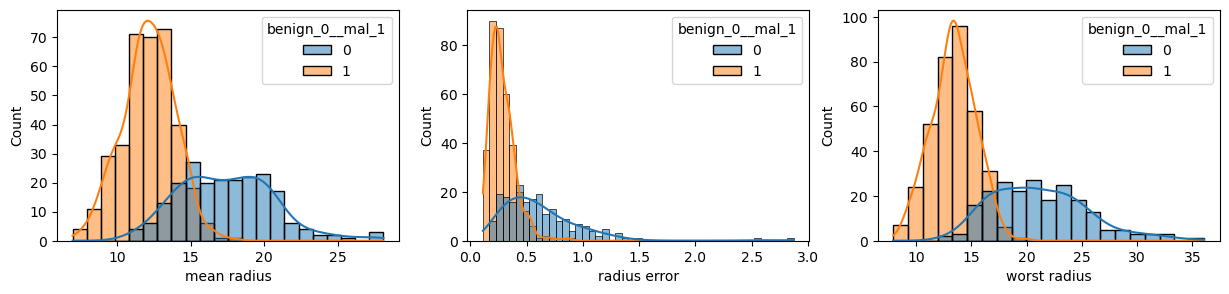

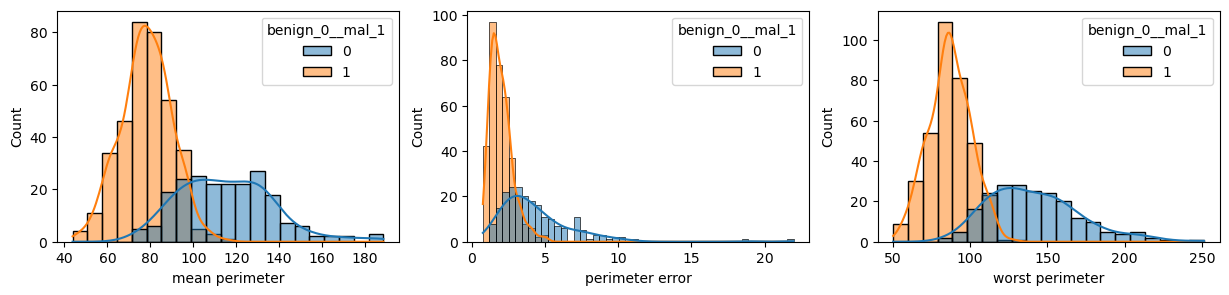

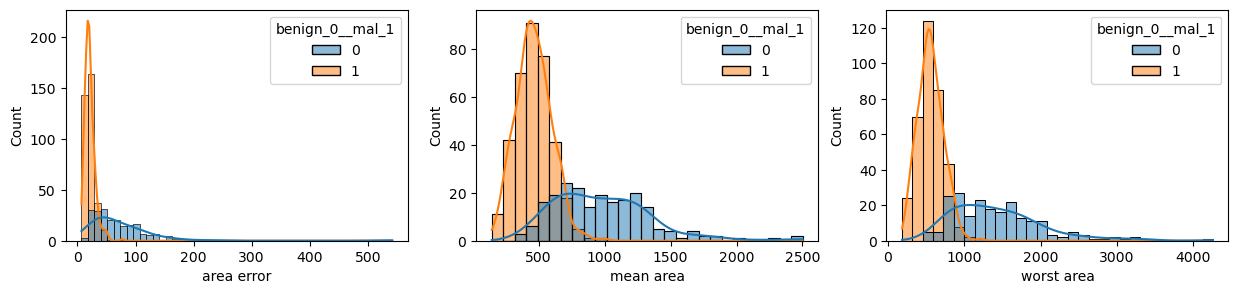

In [12]:
# geometric columns
plot_trait(df, "radius")
plot_trait(df, "perimeter")
plot_trait(df, "area")

- **Curved Metric Column Data Distribution**

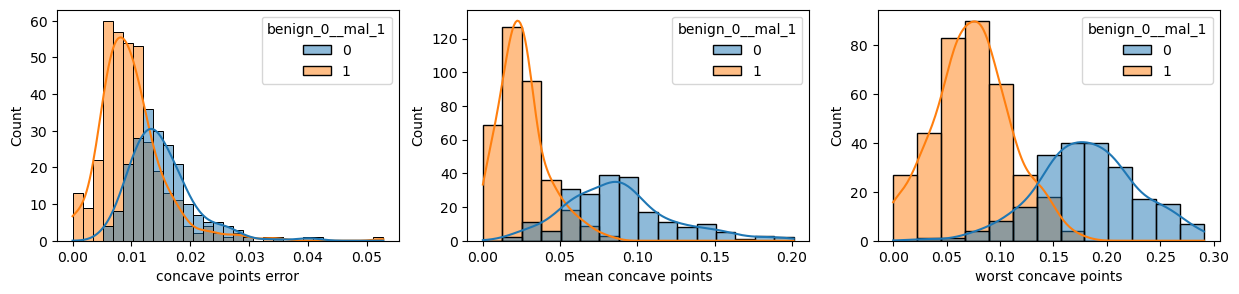

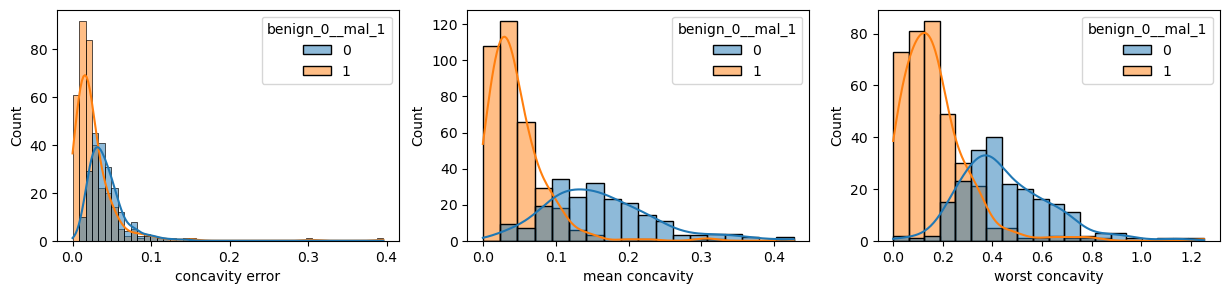

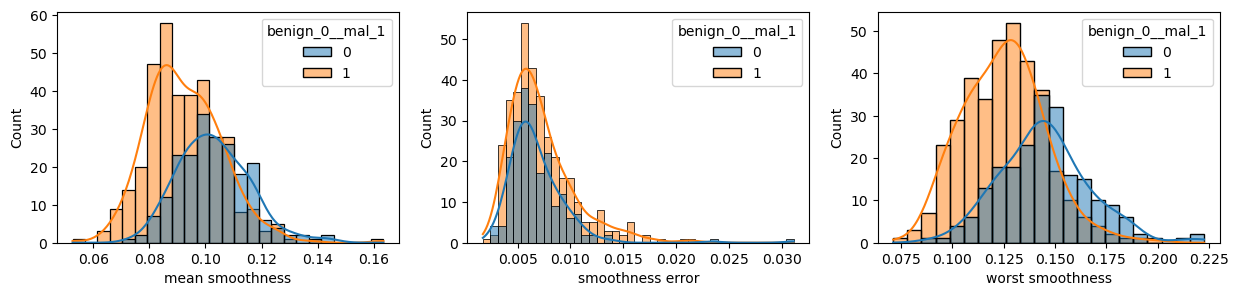

In [13]:
# curved metric columns
plot_trait(df, "concave points")
plot_trait(df, "concavity")
plot_trait(df, "smoothness")

- **Surface Metric Column Data Distribution**

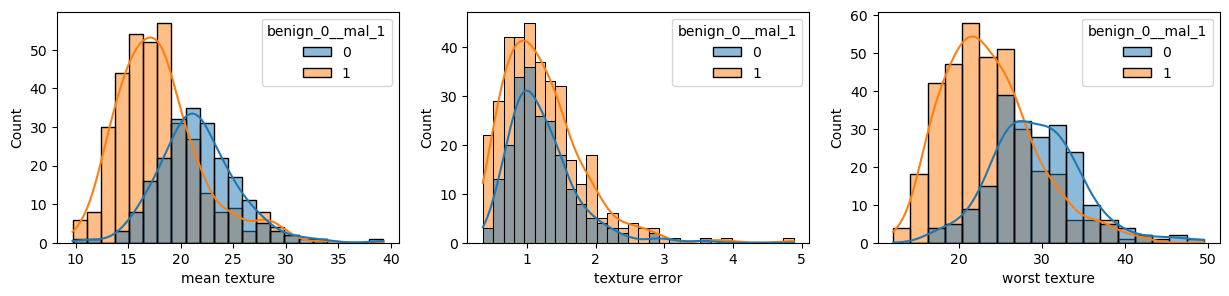

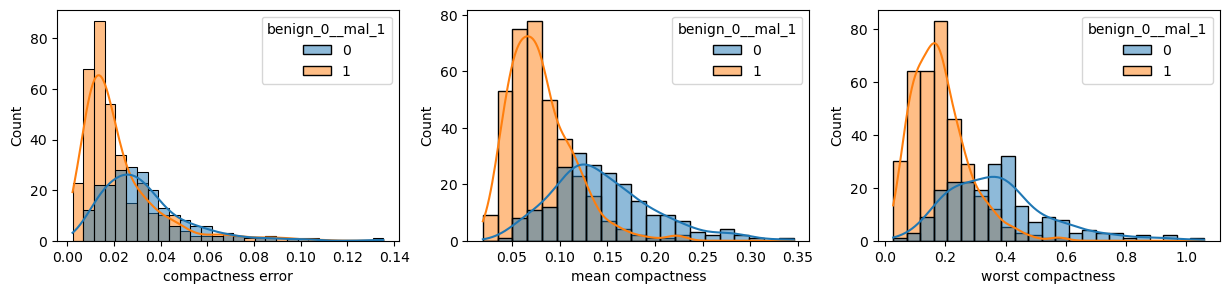

In [14]:
# surface metric columns 
plot_trait(df, "texture")
plot_trait(df, "compactness")

- **Spatial Metric Column Data Distribution**

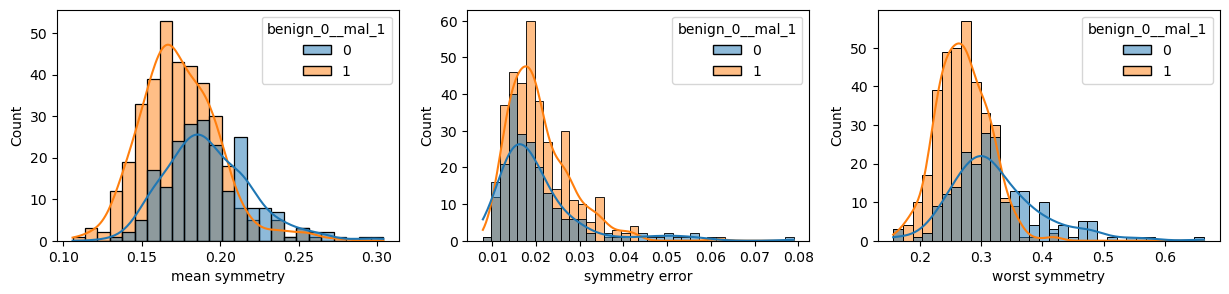

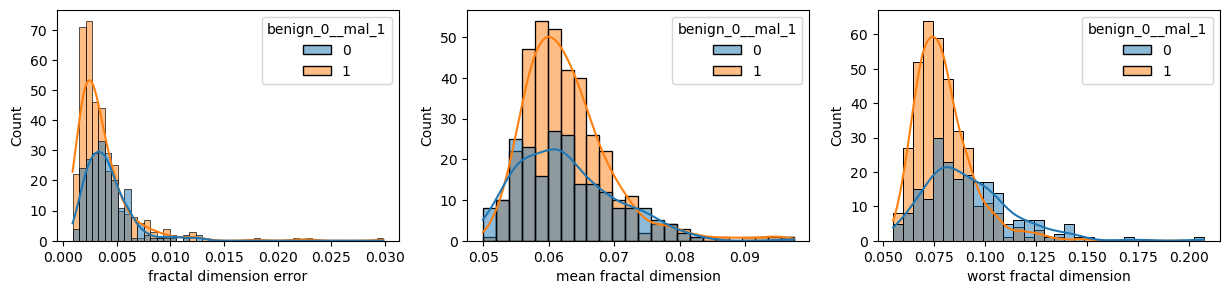

In [15]:
# surface metric columns
plot_trait(df, "symmetry")
plot_trait(df, "fractal dimension")

**Geometric Column Data Distribution** (radius, perimeter, area)
1. **Data Distribution** : all features show unqiue right-skewed distributions, expecially for the malignant class entries.
2. **Class Seperation** : there is good seperation between malignant and benign classes for all variables. Malignant cells are consistently smaller in metric size. 
3. **Impact on Model** : these variables have high predictive power but there is severe multicollinearity because perimeter and area depend on the radius.

**Curved Metric Column Data Distribution**(smoothness, concavity, concave points)
1. **Data Distribution** : smoothness follows a normal ditribution, while the other two variables are heavily right-skewed.
2. **Class Seperation** : smoothness has heavy class overlap so the class seperation is weak. On the other hand, concavity and concave points have minimal overlap, with most of the malignant classes clustering around zero.
3. **Impact on Model** : concavity and concave points are to assumed to be predictors while smoothness may not have the statistical power nesscessary. 

**Surface Metric Column Data Distribution**(texture and compactness)
1. **Data Distribution** : compactness is right-skewed while texture is slightly normally distributed.
2. **Class Seperation** : texture has high class overlap with no clear seperation while compactness provides better seperation with less clas soverlap from the datapoints.
3. **Impact on Model** : compactness has good correlation with the geometric size metrics mentioned earlier, while texture may need to be combined with another variable to be more effective.

**Spatial Metric Column Data Distribution** (symmetry and fractal dimension)
1. **Data Distribution** : symmetry is normally distributed while fractal dimension is heavily right-skewed.  
2. **Class Seperation** : the class seperation is terrible for both variables because the class distributions overlap.
3. **Impact on Model** : both variables may have low individual predictive power because the target classes overlap so much.

(Geeksforgeeks, 2025).

- **Correlation Matrix**

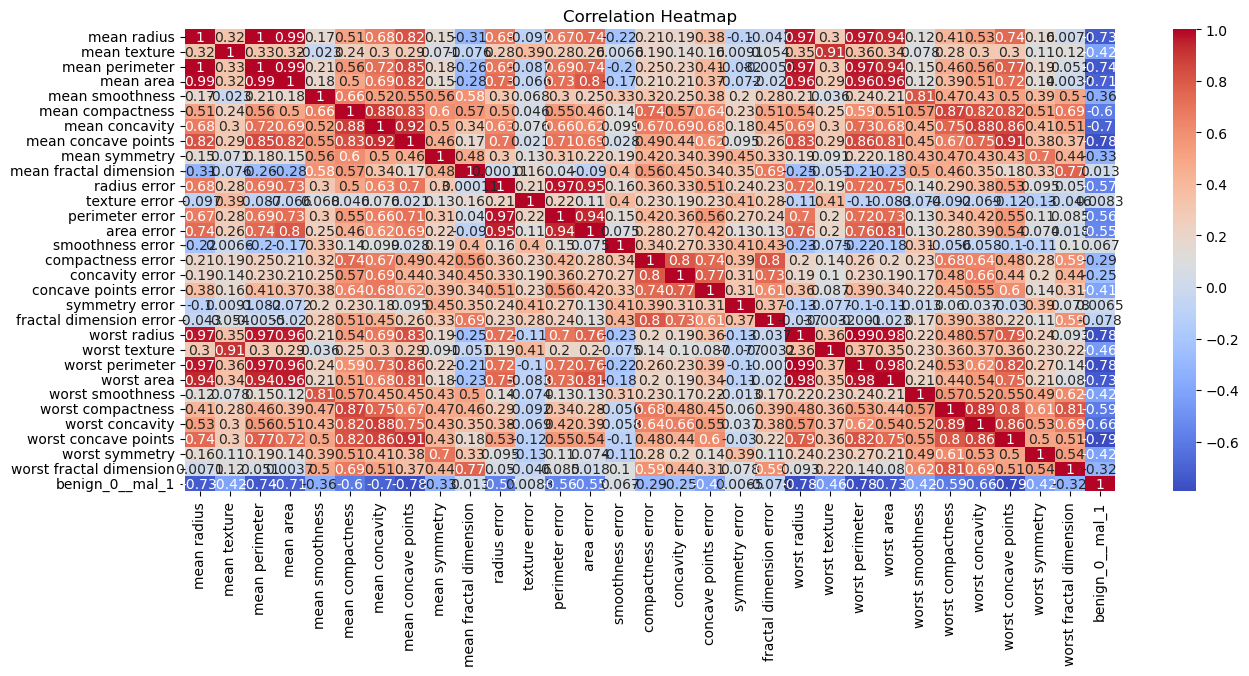

In [16]:
# visualizing correlations
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# correlations sorted list
df.corr(numeric_only=True)['benign_0__mal_1'].sort_values()

worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

**The correlation matrix** indicates that:

- **Strong Multicollinearity** : all the bright red squares indicate that the features in this dataset exhibit high multicollinearity. For instance, mean radius , mean perimeter and mean area correlate almost perfectly (0.99) with one another. This confirms that certain variables, like mean perimeter and mean area, may be redundant and need to be dropped.
- **Strong Predictors** : the bottom row of the matrix shows that many there are many negative feature and target variable correlations. For instance, the top predictors worst concave points (-0.79), worst perimeter (-0.78), and worst radius (-0.78) have the strongest correlations with the target.

(James et al., 2023).

#### - **3.3. Feature Selection (Manual VIF Approach)**

- **Removing Redundant Features**

In [18]:
# 1. remove the two largest multicollinear variables
X_stage1 = df.drop(columns=['mean radius', 'mean perimeter'])

In [20]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage1.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature          VIF
0                     const  1516.067273
19             worst radius   370.508606
21          worst perimeter   346.716926
22               worst area    81.011507
9              radius error    68.506923
11          perimeter error    66.155996
5            mean concavity    65.859765
6       mean concave points    59.973456
2                 mean area    38.691616
24        worst compactness    35.663457
26     worst concave points    35.331014
12               area error    34.381801
4          mean compactness    32.176667
25          worst concavity    31.720547
28  worst fractal dimension    18.833956
20            worst texture    18.190668
14        compactness error    15.341672
8    mean fractal dimension    15.152408
15          concavity error    14.773924
1              mean texture    11.733576
23         worst smoothness    10.651380
16     concave points error    10.512201
18  fractal dimension error     9.639392
27           wor

In [21]:
# 2. remove redundant geometric variables
X_stage2 = X_stage1.drop(columns=['worst perimeter', 'radius error'])

In [22]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage2.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature          VIF
0                     const  1359.313657
18             worst radius   100.956637
20               worst area    72.359431
5            mean concavity    64.907132
6       mean concave points    57.958146
24     worst concave points    34.591941
22        worst compactness    34.525043
23          worst concavity    31.700449
4          mean compactness    30.861923
2                 mean area    29.169519
11               area error    22.463874
10          perimeter error    19.216783
26  worst fractal dimension    18.421485
19            worst texture    17.749751
13        compactness error    14.981713
8    mean fractal dimension    14.878179
14          concavity error    14.579720
1              mean texture    11.467439
21         worst smoothness    10.617540
15     concave points error    10.358878
25           worst symmetry     9.266367
17  fractal dimension error     9.091807
3           mean smoothness     7.956436
16           sym

In [23]:
# 3. eliminate major multicollinear variables
X_stage3 = X_stage2.drop(columns=['worst area', 'mean area', 'mean concave points'])

In [24]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage3.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature         VIF
0                     const  752.311873
19        worst compactness   33.828523
3          mean compactness   29.262617
4            mean concavity   28.587621
20          worst concavity   27.959917
21     worst concave points   24.899001
23  worst fractal dimension   18.073433
17            worst texture   17.392107
8           perimeter error   15.913937
9                area error   14.788954
11        compactness error   14.740606
12          concavity error   12.501262
6    mean fractal dimension   12.167324
16             worst radius   11.881186
1              mean texture   11.323344
13     concave points error   10.304934
18         worst smoothness   10.166853
22           worst symmetry    9.137543
15  fractal dimension error    8.998216
2           mean smoothness    6.869103
14           symmetry error    5.001493
5             mean symmetry    4.064097
7             texture error    3.993186
10         smoothness error    3.856202


In [25]:
# 4. eliminate major multicollinear variables
X_stage4 = X_stage3.drop(columns=['worst compactness', 'mean compactness', 'perimeter error'])

In [26]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage4.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature         VIF
0                     const  528.227854
18     worst concave points   23.713572
17          worst concavity   22.908821
3            mean concavity   20.471464
15            worst texture   17.319577
20  worst fractal dimension   13.452573
1              mean texture   11.228500
14             worst radius   11.037723
10          concavity error   10.660693
16         worst smoothness   10.147282
5    mean fractal dimension    8.869012
11     concave points error    8.838516
19           worst symmetry    8.762184
13  fractal dimension error    7.644390
2           mean smoothness    6.417617
9         compactness error    6.303963
12           symmetry error    4.821973
4             mean symmetry    3.916304
6             texture error    3.872760
7                area error    3.783900
8          smoothness error    3.731376


In [27]:
# 5. eliminate major multicollinear variables
X_stage5 = X_stage4.drop(columns=['worst concavity', 'worst texture'])

In [28]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage5.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature         VIF
0                     const  522.365468
16     worst concave points   21.846467
3            mean concavity   15.474272
14             worst radius   10.937343
18  worst fractal dimension    9.354008
15         worst smoothness    9.234185
11     concave points error    8.171284
5    mean fractal dimension    7.946292
17           worst symmetry    7.763192
10          concavity error    7.540343
13  fractal dimension error    6.278916
2           mean smoothness    6.207052
9         compactness error    5.951242
12           symmetry error    4.265922
4             mean symmetry    3.753112
7                area error    3.714428
8          smoothness error    3.562690
6             texture error    2.010276
1              mean texture    1.726915


In [29]:
# 6. eliminate last multicollinear variables
X_stage6 = X_stage5.drop(columns=['mean concavity', 'worst radius'])

In [30]:
# check new VIF scores
# VIF code adapted from: 
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
# https://gustavorsantos.medium.com/calculating-variance-inflation-factor-vif-in-python-49e5f48f33bf

# import tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# VIF score cannot be done without dropping target and adding a constant
X = add_constant(X_stage6.drop('benign_0__mal_1', axis=1))

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data.sort_values(by='VIF', ascending = False))

                    feature         VIF
0                     const  210.231820
16  worst fractal dimension    9.128818
13         worst smoothness    8.781378
14     worst concave points    8.577702
15           worst symmetry    7.335936
4    mean fractal dimension    7.025078
10     concave points error    6.112628
8         compactness error    5.867022
2           mean smoothness    5.846553
12  fractal dimension error    5.707066
11           symmetry error    4.142986
9           concavity error    3.970440
3             mean symmetry    3.563220
7          smoothness error    3.486569
6                area error    2.134391
5             texture error    2.001772
1              mean texture    1.673955


**Based on the EDA**, certain feature variables should be dropped from the dataset before modelling. Due to extreme multicollinearity, as confirmed by Variance Inflation Factors (VIF), a **six stage method** was used to remove certain redundant feature variables.
1. **Stage 1 & 2** : mean radius, mean perimeter, worst perimeter, and radius error were all removed because their VIF scores were extremely high. This is likely due to geometric overlap.
2. **Stage 3** : worst area, mean area, and mean concave points were all dropped. This made all other VIF scores drop.
3. **Stage 4 & 5** : worst compactness, mean compactness, perimeter error, worst concavity, and worst texture were removed because they had very high VIF scores. This means the variables are redundant because they overlap.
4. **Stage 6** : mean concavity and worst radius were dropped because their VIF scores still remained extremely high. The resulting feature variable makeup has VIF scores under the threshold (10).

**The following variables** were removed:

**IN** 
- **worst fractal dimension (9.13 VIF)**
- **worst smoothness (8.78 VIF)**
- **worst concave points (8.58 VIF)**
- **worst symmetry (7.34 VIF)**
- **mean fractal dimension (7.03 VIF)**
- **concave points error (6.11 VIF)**
- **compactness error (5.87 VIF)**
- **mean smoothness (5.85 VIF)**
- **fractal dimension error (5.71 VIF)**
- **symmetry error (4.14 VIF)**
- **concavity error (3.97 VIF)**
- **mean symmetry (3.56 VIF)**
- **smoothness error (3.49 VIF)**
- **area error (2.13 VIF)**
- **texture error (2.00 VIF)**
- **mean texture (1.67 VIF)**

**OUT** 

Dropped for geometric size redundancy and high VIF scores.
- **mean radius**
- **mean perimeter**
- **worst perimeter**
- **mean area**
- **worst area**
- **radius error**
- **perimeter error**

Dropped for redundancy and high VIF scores.
- **mean concave points**
- **worst compactness**
- **mean compactness**
- **worst concavity**
- **mean concavity** 
- **worst texture and worst radius** 

#### 4. Model Training and Optimising
#### - **4.1. Split Data**

In [31]:
# dropping useless columns
df_clean = X_stage6.copy()

# splitting data into X and y
target_column = 'benign_0__mal_1'

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

# checking if the split worked
print (y.head()) 
print (X.head())

0    0
1    0
2    0
3    0
4    0
Name: benign_0__mal_1, dtype: int64
   mean texture  mean smoothness  mean symmetry  mean fractal dimension  \
0         10.38          0.11840         0.2419                 0.07871   
1         17.77          0.08474         0.1812                 0.05667   
2         21.25          0.10960         0.2069                 0.05999   
3         20.38          0.14250         0.2597                 0.09744   
4         14.34          0.10030         0.1809                 0.05883   

   texture error  area error  smoothness error  compactness error  \
0         0.9053      153.40          0.006399            0.04904   
1         0.7339       74.08          0.005225            0.01308   
2         0.7869       94.03          0.006150            0.04006   
3         1.1560       27.23          0.009110            0.07458   
4         0.7813       94.44          0.011490            0.02461   

   concavity error  concave points error  symmetry error  \
0  

In [32]:
# importing tool for splitting
from sklearn.model_selection import train_test_split

# defining training and test groups
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**This dataset** into now split into a training set and a test set using the **X and y** variables established in the previous code block. **Splitting the data** into training and test groups before any scaling or modelling avoids potential data leakage problems that can make models overfit (Müller & Guido, 2016).

#### - **4.2. Feature Scaling**

- **Standardisation**

In [33]:
# import neccessary tools
from sklearn.preprocessing import StandardScaler

# define the scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Scaling** involves changing the data distribution of certain variables in a dataset so that all variables are on the same numerical scale. **Standardisation** is a type of scaler used when a few of the variables being used are normally distributed. The datapoints are transformed into values with a mean of 0 and standard deviation of 1, thereby putting them all on the same scale while maintaining data shape (Caldwell, 2013).

**In this case** standardisation is used because the variables in question are scaled differently. These numerical features needed to be scaled because models are more favourable to variables with bigger values. **The target variable** remains untouched because binary variables get messy if they are scaled (Müller & Guido, 2016).

#### - **4.3. Model Training**

In [34]:
# import libraries needed
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

**Three ML models** are trained : 

1. **Logistic Regression**

In [35]:
# initialize and train
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


2. **RandomForest**

In [36]:
# initialize and train
rf = RandomForestClassifier()
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


3. **Support Vector Machine (SVC)**

In [37]:
# initialize and train
svc = SVC()
svc.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


**Researchers** need to train their models using a training dataset before predicting. In this case, the following models are being trained:

1. **Logistic Regression** : this is easy to interpret because of the odd ratio. This tells us about the odds of the target outcome.
- **> 1.0** = positive predictor (positive relationship with target outcome)
- **< 1.0** = negative predictor (negative relationship with target outcome)

2. **Random Forest** : this model captures non-linear relationships unlike logistic regression. This measures **feature importance** which can tell us about the impact of certain features.
* These score are between 0.0 and 1.0.
* Higher scores mean the model relied more on those specific features to split datapoints.

3. **Support Vector Classifier (SVC)** :  this model is implemented using a non-linear **RBF (Radial Basis Function) kernel**. This makes use of a higher-dimensional boundary.
* Support vectors are used to create the decision margin.

(James et al., 2023).

#### - **4.4. Model Coefficients**

In [38]:
# logistic regression model coefficients
print(f"Intercept: {lr.intercept_[0]:.2f}\n")

for feature, coef in zip(X.columns, lr.coef_[0]):
    print(f"{feature}: {coef:.2f}")

Intercept: 0.91

mean texture: -1.16
mean smoothness: -0.43
mean symmetry: 0.36
mean fractal dimension: 1.22
texture error: -0.07
area error: -3.39
smoothness error: -0.13
compactness error: 0.21
concavity error: -0.20
concave points error: -0.26
symmetry error: 0.75
fractal dimension error: 0.49
worst smoothness: -0.28
worst concave points: -2.74
worst symmetry: -1.42
worst fractal dimension: -0.33


**This shows that** the Logistic Regression model uses an intercept of **0.91**. Some of the strong negative coefficeints belong to **area error (-3.39)** and **worst concave points (-2.74)**. These variables drive the models prediction toward class 0 (Benign). On the other hand, the strongest variables, such as **mean fractal dimension (1.22)** and **symmetry error (0.75)**, push the model to predict class 1 (malignant). 

In [39]:
# random forest model coefficients
print("Model Feature Importances:")

for feature, imp in zip(X.columns, rf.feature_importances_):
    print(f"{feature}: {imp:.2%}")

Model Feature Importances:
mean texture: 5.60%
mean smoothness: 2.50%
mean symmetry: 1.22%
mean fractal dimension: 3.35%
texture error: 1.04%
area error: 18.98%
smoothness error: 1.83%
compactness error: 1.76%
concavity error: 5.99%
concave points error: 3.15%
symmetry error: 1.69%
fractal dimension error: 1.67%
worst smoothness: 4.44%
worst concave points: 39.83%
worst symmetry: 4.94%
worst fractal dimension: 2.02%


**This shows** that the models primary drivers are **worst concave points (39.83%)** and **area error (18.98%)**. Together these two make up more than 55% of the models predictive power. The lower predictors include **mean texture (5.60%)**, **concave points error (3.15%)**, and **worst symmetry (4.94%)**. **Similar to the logistic classifier**, this models top features are **worst concave points** and **area error**. This confirms that these variables are powerful predictors.

In [40]:
# check support vectors
print("Support Vectors per class:", svc.n_support_)

Support Vectors per class: [67 76]


**The SVM Classifier** built uses a non-linear RBF kernel. The total support vectors used in this case was **143 support vectors**, with **67 points from class 0** and **76 points from class 1**. This balanced distribution of classes confirms that the decision boundary is accurate (James et al., 2023).

#### 5. Model Evaluation and Interpretation
#### - **5.1. Predictions**

In [41]:
# making predictions
lr_predictions = lr.predict(X_test_scaled)
rf_predictions = rf.predict(X_test_scaled)
svc_predictions = svc.predict(X_test_scaled)

#### - **5.2. Performance Analysis**

**In this notebook**, recall (sensitivity) is prioritised because from a clinical viewpoint, missed diagnoses or false negatives can have horrific consequences and should be avoided. Focusing on recall will allow the models to conform to this perspective, ensuring the least amount of false negatives as possible. The following is a list of metrics used in this step: 

- **Precision** : how many predicted positives were correct? (lowers false positives)
- **Recall (Prioritised)** : how many true positives were caught? (critical because it lowers false negatives)
- **F1-score** : how good is the model at not predicting false positives? (balance between precision and recall)
- **Accuracy** : how many true values (positive and negative) were predicted correctly? (overall percentage of correct predictions)
- **Confusion Matrix** : breakdown of true positives, true negatives, false positives (false alarms), and false negatives (dangerous misses) 
- **ROC curve (AUC score)** : how well can the model seperate? (evaluates model using area under curve score)

(James et al., 2023).

1. **Logistic Regression**

<Axes: >

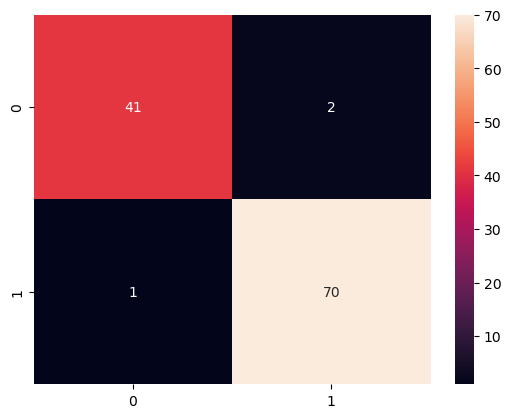

In [45]:
# import libraries 
from sklearn.metrics import confusion_matrix, classification_report

# logistic regression evaluation
sns.heatmap(confusion_matrix(y_test, lr.predict(X_test_scaled)), annot=True)

In [47]:
# training score
lr_train_score = lr.score(X_train_scaled, y_train)
print(f"Training Accuracy: {lr_train_score:.2%}")
print (classification_report(y_test, lr.predict(X_test_scaled)))

Training Accuracy: 98.24%
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



**The Confusion Matrix** shows that in total there are 114 test samples, with 43 being class 0 (benign) and 71 being class 1 (malignant) :
- **41 true negatives** samples were correctly identified by the model and **2 false positives** occured.
- **70 true positive** datapoints were correctly identified by the model and **1 false negative** occured
(Dalianis, 2018).


**The classification report** shows that the logistic regression model has a test **accuracy of 97%**, and therefore has high generalization capabilities. **This confirms** that this model is highly accurate; almost no mistakes were make when predicting on the test set. In terms of **accuracy**, compared to it's **training score (98.24%)**, the models **test score (97%)** is not far behind, indicating that the model fits the dataset perfectly (no overfitting). With a malignant recall of 0.99, and only 1 false negative case, this model is extremely successful at catching true positives while ensuring no false negatives (missed diagnoses) occur (Caldwell, 2013).

The **training score** will often be higher than the **test score** due to random chance, otherwise known as sampling error (Caldwell, 2013). **Next**, an ROC curve will be used to further evaluate the model.

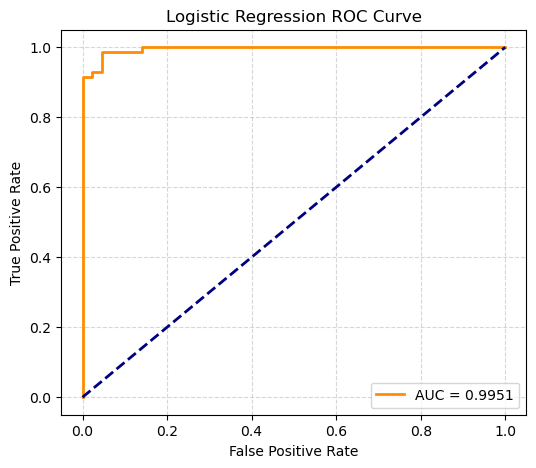

In [75]:
# import libraries
from sklearn.metrics import auc, roc_curve

# probabilities
y_probs = lr.predict_proba(X_test_scaled)[:, 1]

# roc values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# auc
roc_auc = auc(fpr, tpr)

# plotting curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")  # Random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)  # Adds a clean background grid
plt.show()

**The ROC curve** allows researchers to gauge how well the model predicts. **In this case**, with a baseline score of 0.50, this model has an **AUC score of 0.9951**, indicating that it is very likely to predict true outcome classes correctly (true positive rate = 1.0) while keeping false positives low (false positive rate = 0.0). The line almost hugs the top left hand corner indicating that the model is a safe and powerful predictor which can be used in the medical field (Müller & Guido, 2016).

2. **RandomForest**

<Axes: >

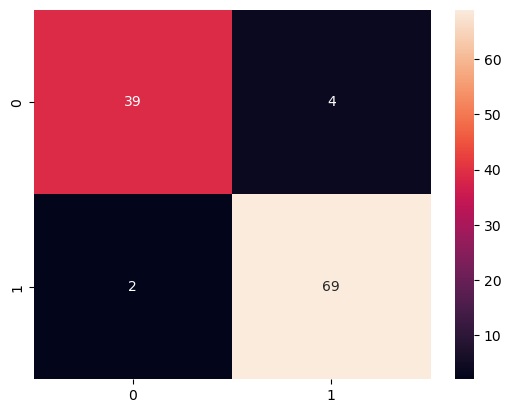

In [48]:
# random forest evaluation
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test_scaled)), annot=True)

In [49]:
# training score
rf_train_score = rf.score(X_train_scaled, y_train)
print(f"Training Accuracy: {rf_train_score:.2%}")
print (classification_report(y_test, rf.predict(X_test_scaled)))

Training Accuracy: 100.00%
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**The Confusion Matrix** shows that in total there are 114 test samples, with 43 being class 0 (benign) and 71 being class 1 (malignant) :
- **38 true negatives** samples were correctly identified by the model and **4 false positives** occured.
- **68 true positive** datapoints were correctly identified by the model and **2 false negative** occured.
(Dalianis, 2018). 

**This information** indicates that the model made exactly 8 misclassifications or mistakes when predicting on the test set. **From the classification report** we can see that the test score is way lower (95%) when compared to the training score (100%); this is a sign of that the model memorised the training data (overfitting). With regards to other metrics, the models malignant **recall (0.97)** score is very high even though it missed 2 diagnoses (2 false negatives). This indicates that, compared to the logistic regression model, the random forest model is less safe for clinical deployment. **Furthermore**, the overfitting needs to be addressed through hyperparameter tuning to fully understand how well the model predicts (Müller & Guido, 2016).

**Next**, an ROC curve will be used to further evaluate the model.

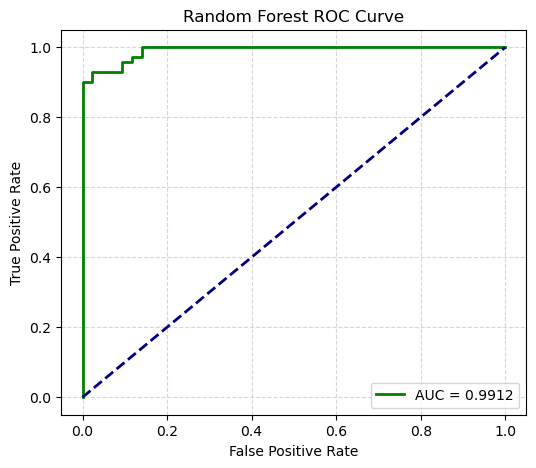

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# probabilities for random forest
rf_probs = rf.predict_proba(X_test_scaled)[:, 1]

# roc values
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# plotting the curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"AUC = {roc_auc_rf:.4f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**In this case**, with a baseline score of 0.50, this model has an **AUC score of 0.9912**. This indicates that despite overfitting, the random forest model can still distinguish between classes extremely well. In comparison, this model sits just under the **logistic regression model (0.9951)** in terms of AUC score (Müller & Guido, 2016).

3. **Support Vector Machine (SVC)**

<Axes: >

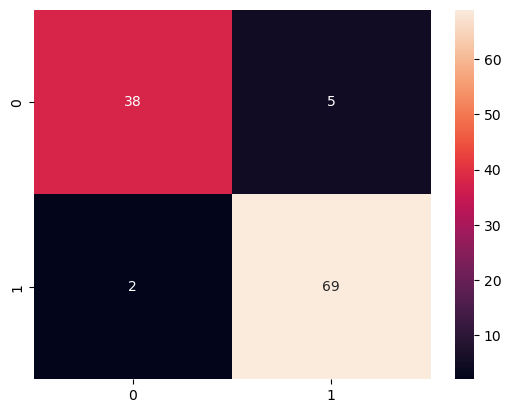

In [50]:
# svm evaluation
sns.heatmap(confusion_matrix(y_test, svc.predict(X_test_scaled)), annot=True)

In [51]:
# training score
svc_train_score = svc.score(X_train_scaled, y_train)
print(f"Training Accuracy: {svc_train_score:.2%}")
print (classification_report(y_test, svc.predict(X_test_scaled)))

Training Accuracy: 98.24%
              precision    recall  f1-score   support

           0       0.95      0.88      0.92        43
           1       0.93      0.97      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



**The Confusion Matrix** shows that in total there are 114 test samples, with 43 being class 0 (benign) and 71 being class 1 (malignant) :
- **38 true negatives** samples were correctly identified by the model and **5 false positives** occured.
- **69 true positive** datapoints were correctly identified by the model and **2 false negative** occured
(Dalianis, 2018). 

**This information** indicates that the model made 7 misclassifications or mistakes when predicting on the test set. **The classification report** reveals that model mildly overfits because the test score (94%) is way lower than the training score (98.24%) (Caldwell, 2013). This model almost remembered 100% of the training data so it could struggle to predict new data. Drawing from other evaluation metrics used, we see that the models malignant **recall (0.97)** is extremely high even though it missed 2 diagnoses (2 false negatives). This shows that, while the support vector classifier performed better than the random forest model (3 false negatives), compared to the logistic regression model (1 false negative), it slightly underperforms and is therefore less safe for deployment. **Additionally**, the slight overfitting indicates that hyperparameter tuning via cross validation may be needed to improve model performance (Müller & Guido, 2016).

**Next**, an ROC curve will be used to further evaluate the model.

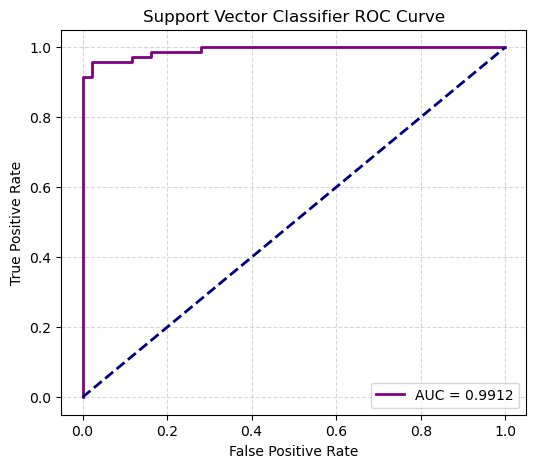

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# 1. Get decision scores for SVC (required instead of predict_proba)
svc_scores = svc.decision_function(X_test_scaled)

# 2. Compute ROC values
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, svc_scores)
roc_auc_svc = auc(fpr_svc, tpr_svc)

# 3. Plot the curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_svc, tpr_svc, color="purple", lw=2, label=f"AUC = {roc_auc_svc:.4f}")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Classifier ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**In this case**, with a baseline score of 0.50, this model has an **AUC score of 0.9912**. This score is identical to the **random forest's AUC score**. While both models almost perfectly distinguish or seperate classes, they both fail to beat the **logistic regression models (0.9951)** AUC score (Müller & Guido, 2016).

#### - **5.3. Hyperparameter Tuning**

**Two models** are suitable for hyperparameter tuning as they may suffer from overfitting. The rationale is that both datasets score higher on their training set than their test sets.
- **RF** : training score (100) vs test score (95)
- **SVC** : training score (98) vs test score (94)

Tuning these models via **cross-validation** will use constraints to smoothen out decision boundaries and improve test set accuracy (Müller & Guido, 2016).

**RandomForest**

In [54]:
# import libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# assign grid search cv
grid = GridSearchCV(RandomForestClassifier(), {"max_depth": [3, 5, 7], "min_samples_split": [2, 5, 10]}, cv=5)
grid.fit(X_train_scaled, y_train)

print(grid.best_params_, "->", grid.best_score_)

# evaluate test set
# random forest
print("Tuned Random Forest Test Accuracy:", grid.score(X_test_scaled, y_test))

{'max_depth': 7, 'min_samples_split': 2} -> 0.9516483516483516
Tuned Random Forest Test Accuracy: 0.9473684210526315


**The above codeblock** automates the hyperparameter tuning process for the random forest model. **Grid Search Cross Validation**  iteratively runs our random forest model until the best parameter combinations are found. Setting the max depth and sample split tells the machine how many tree depths to test paired with how many splits to test in order to find the best combination. The CV = 5 score ensures stability and represents how many groups the training data is split into.

**The results show** that the tree performs best at a maximum depth of 7 (max_depth: 7), indicating that for this particular dataset, the threshold before the tree starts memorizing the training data noise is seven splits. Additionally, it shows that for the best model to be fit on this dataset, a branch should only be allowed to split with a minimum 2 data points inside it. This stops the model from overfitting, as evident by the new improved training score of 95% (0.95) and new test score of 95% (0.95); old training score (100) vs test score (95).

**Overall**, the new tuned random forest model still underperforms compared to the **logistic regression model (97.37% test accuracy)**.

(Müller & Guido, 2016).

**SVC**

In [86]:
# import libraries
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# assign grid search cv
grid_svc = GridSearchCV(SVC(), {"C": [0.1, 1, 10], "gamma": ["scale", "auto"]}, cv=5)
grid_svc.fit(X_train_scaled, y_train)

print(grid_svc.best_params_, " = ", grid_svc.best_score_)

{'C': 10, 'gamma': 'scale'} -> 0.9604395604395604


In [87]:
# test evaluation
# svc
print("Tuned SVC Test Accuracy:", grid_svc.score(X_test_scaled, y_test))

Tuned Random Forest Test Accuracy: 0.956140350877193
Tuned SVC Test Accuracy: 0.9385964912280702


**The above codeblock** automates hyperparameter tuning for the Support Vector Classifier. **Grid Search Cross Validation** iteratively runs our SVC model until the best parameter combinations are found. Using the C regularisation penalty as well as y (gamma) allows the machine to dictate which combination of penatly strenght and feature distance is the best. 

**The results show** that the model performs the best with a C (regularisation) value of 10. This is higher penalty forces the classifier to fix the training score, as seen by the new training score above **(96%)**. **However, this** new tuned SVC model may still slightly struggle with generalization. This is evident because the **new training score (96%)** is still lower than the **new test score (94%)**

While it achieved a high **96.04%** score during cross validation, its performance dropped back down to **93.86%** on the test set. Compared to the old training score (98) and test score (94), this tuned svc model performed less accurately. **Overall**, this model still underperforms compared to the **logistic regression model (97.37% test accuracy)**.

(James et al., 2023; Müller & Guido, 2016).

#### - **5.4. Evaluation**

| Model | Training score | Test score | Tuning | CV score | Final accuracy | Malignant recall (Class 1) |
| :--- | :---: | :---: | :--- | :---: | :---: | :---: |
| **Logistic Regression** | 98.24% | **97%** | *None* | — | **97% (WINNER)** | **99%** |
| **Random Forest** | 100.00% | 94% | `{'max_depth': 5, 'min_samples_split': 2}` | 95.16% | 96% | 96% |
| **Support Vector Classifier** | 98.24% | 94% | `{'C': 10, 'gamma': 'scale'}` | 96.04% | 94% | 97% |

**The results** support the assumptions made during exploratory data analysis. **The worst concave points** and **area error variables** are the primary predictors, as identified in the EDA. This is backed by the fact that together these variables hold more than 57% of the total importance for the **random forest model** and also have the largest negative coefficients in the **logistic regression model**. This could suggest that extreme cellular abnormalities (size, texture, concavity and more) are more typical of malignancy. **Other features** like **texture error** and **mean symmetry** exhibit no standalone impact on the final predictions. 

**Initially**, two of the three moedls suffered from setbacks (overfitting) and had to be tuned using cross validation. The **SVC** model has an initial **training score of 98.24%** and **test score of  94%**. This slight overfitting encouraged the use of hyperparameter tuning, but this dropped the **training set score (96.04%)** without increasing the **test set accuracy (94%)**. **In contrast**, the **initial random forest model** memorized the training dataset perfectly **(100.00% accuracy)** but dropped heavily on the test set **(94%)**. This overfitting was fixed using hyperparameter tuning to change the **training (95.16%)** and **test score (95.61%)**.

**Lastly**, **logistic regression** had the lowest margin between its training score (98.24%) and its test score (97.37%). This confirms that this model is the best suited for this cancer classification probelm because it is the safest model with the lowest false negative rate **(highest recall 99%)**. This model only missed **1 true positive** and had **2 false positives** out of **71 patients**. In comparison, **both other models** has 2 false negatives. The **simplicity** of the **logistic regression** may have given it an advantage; all other models were to complex even after tuning for this dataset.

#### 6. Conclusion
#### - **6.1.Recommendations**

**The logistic regression** model was found to be the best model, however, this may be enhanced by:
- **Feature engineering** : using a different feature engineering method like **Principal Component Analysis (PCA)** before model training might allow for better results becuase no features are manually dropped. **Instead**, features are turned into components that would take away any redundancy or possible noise. This may help control fit of the **random forest** and **SVM** models

- **Different model** : testing a different model, such as k-nearest neighbors, may prove effective because non-parametric distance models often catch data patterns that parametric ones miss.

- **Extreme feature engineering** : creating interaction terms for variables may allow models to produce even higher accuracy scores. 

- **Class balancing** : the target variable in this dataset is slightly imbalance so training and test sets are also slightly imbalanced. Using a resampling technique like **SMOTE** before cross validation may help balance the classes, potentially increasing model accuracy.

(James et al., 2023).

#### - **6.2.Synopsis of Research and Findings**

This machine learning project evaluated the predictive power of three models, namely **logistic regression**, **random forest**, and a **support vector classifier (SVC)**. **Overall**, the best performing model (logistic regression) achieved **97.37% test accuracy** and **99.00% class 1 (malignant) recall**. This is comparative to other research done using similar datasets for cancerclassification. 

For example, using the same 30 feature dataset, researchers reported an accuracy of **98.25%**, an **AUC score of 0.99**, and only 2 classification errors; **one false negative and one false positive**. In comparison, both models have almost idenitical AUC scores (0.99) and also have only one missing true positive case (Cheng and Yu, 2025). **Another researcher** found that by filtering the data of outliers and redundant features, the accuracy score for both **logistic regression** and **random forest** models can be improved from **98.25%** to **99%** (Juarto, 2023). While the this research does show that more preprocesisng can increase model performance, it also shows that the **high predictors (worst concave points and area error)** identified in this study are justified.

#### 7. References

Caldwell, S. (2013). Statistics unplugged (4th ed.). Cengage Learning.

Cheng, W., & Yu, Z. (2025). A fast and interpretable Logistic Regression framework for breast tumor classification using the Wisconsin Diagnostic dataset (Preprint). medRxiv. https://doi.org/10.64898/2025.12.23.25342946

Dalianis, H. (2018). Evaluation metrics and evaluation. In H. Dalianis (Ed.), Clinical text mining: Secondary use of electronic patient records (pp. 45–53). Springer. https://doi.org/10.1007/978-3-319-78503-5_6

Hastie, T., Tibshirani, R., & Friedman, R. (2017). The elements of statistical learning: Data mining, inference, and prediction (2nd ed.). Springer.

Interpretations of histograms. (2025). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/interpretations-of-histogram/

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer.

Juarto, B. (2023). Breast cancer classification using outlier detection and Variance Inflation Factor. Engineering, Mathematics and Computer Science (EMACS) Journal, 5(1), 17–23. https://www.bing.com/ck/a?!&&p=a0aeb658d09fe17877e60fb890c3a2552ffe98a78aafb1c1d955e2cd2c8420e7JmltdHM9MTc3OTMyMTYwMA&ptn=3&ver=2&hsh=4&fclid=2bdd5b5c-bb6f-6aee-05bd-4c08baa66beb&psq=Juarto%2c+B.+(2023).+Breast+cancer+classification+using+outlier+detection+and+Variance+Inflation+Factor.+Engineering%2c+Mathematics+and+Computer+Science+(EMACS)+Journal%2c+5(1)%2c+17%e2%80%9323.&u=a1aHR0cHM6Ly9qb3VybmFsLmJpbnVzLmFjLmlkL2luZGV4LnBocC9FTUFDUy9hcnRpY2xlL3ZpZXcvOTIyMw 

Müller, A. C., & Guido, S. (2016). Introduction to machine learning with Python: A guide for data scientists. O'Reilly Media.